In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\DELL\\Videos\\insurance.csv")

In [3]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.shape

(1340, 10)

In [6]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [7]:
sns.set(style='whitegrid', palette='Set2', font_scale= 1.1)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [10]:
df.dropna(inplace = True)

In [11]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [12]:
df.shape

(1332, 10)

In [13]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


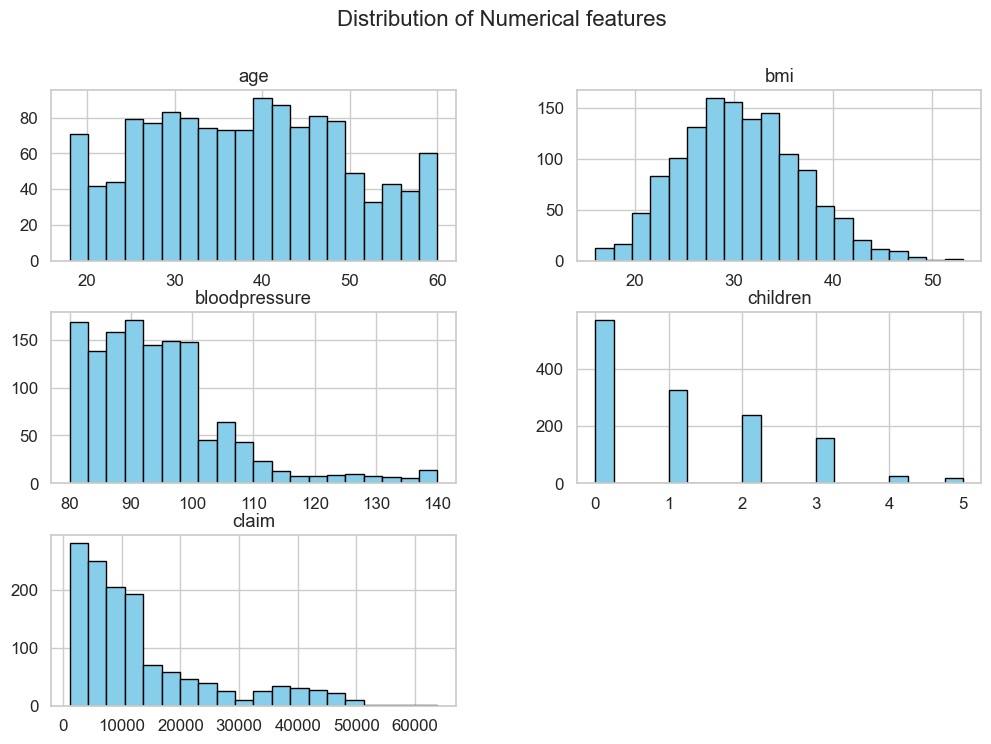

In [14]:
numeric_cols =['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[numeric_cols].hist(bins=20, figsize= (12,8), color = 'skyblue', edgecolor = 'black')
plt.suptitle('Distribution of Numerical features', fontsize = 16)
plt.show()

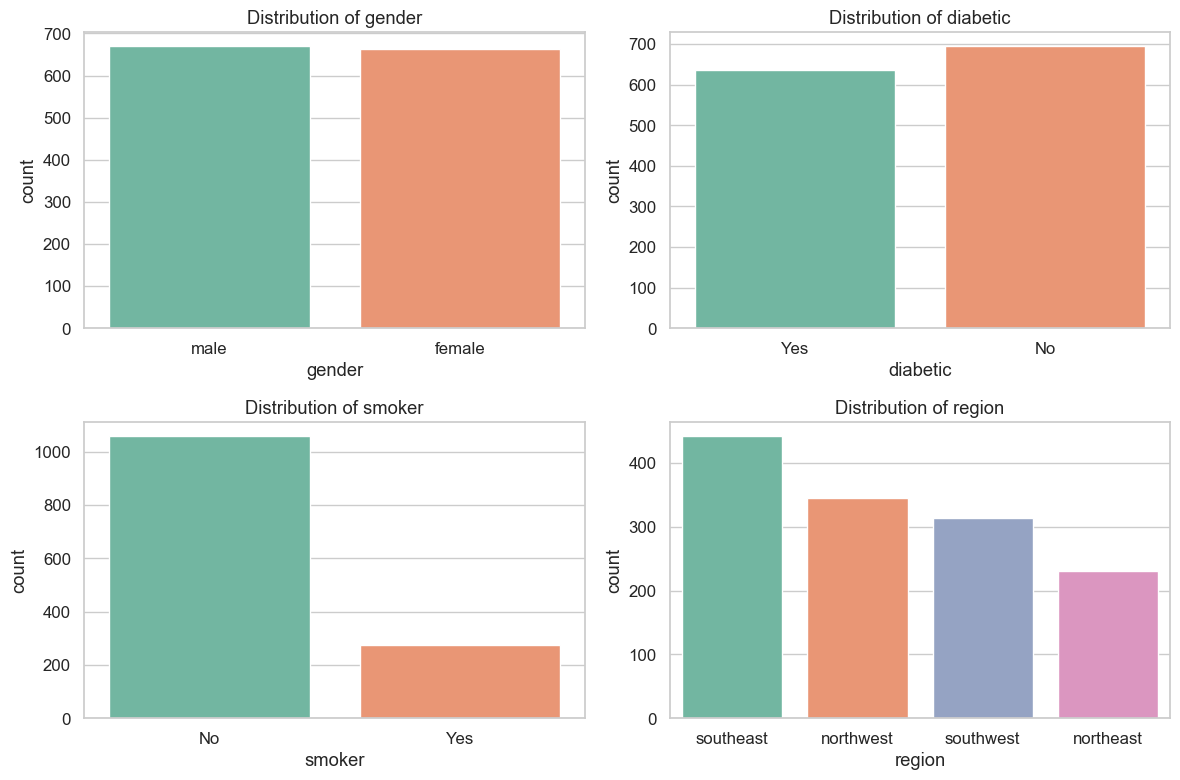

In [15]:
cat_cols = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x = col, hue = col, palette = 'Set2')
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [16]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

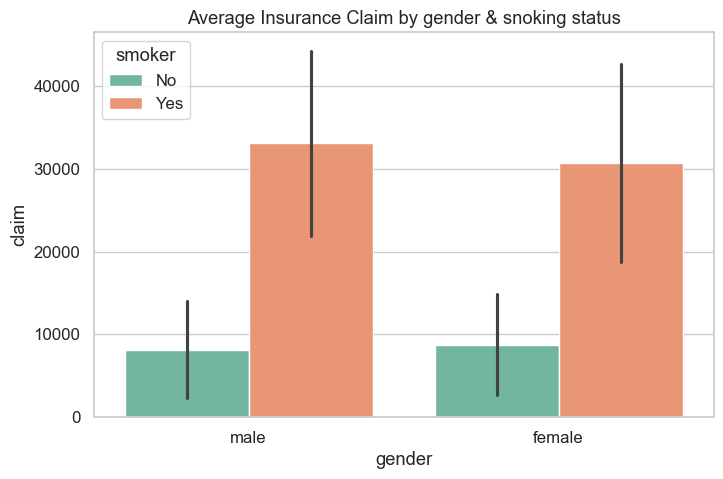

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = 'gender', y = 'claim', hue = 'smoker', estimator = 'mean', errorbar = 'sd' )
plt.title('Average Insurance Claim by gender & snoking status')
plt.show()

In [18]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()

In [19]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


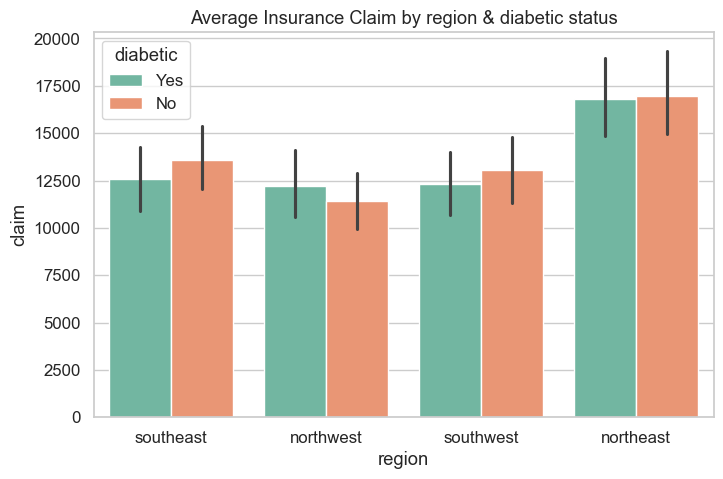

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = 'region', y = 'claim', hue = 'diabetic', estimator = 'mean')
plt.title('Average Insurance Claim by region & diabetic status')
plt.show()

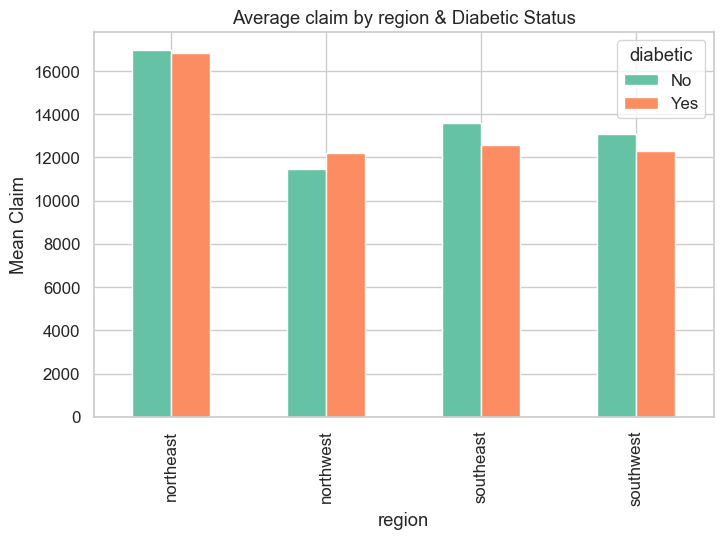

In [21]:
pivot_region_diabetic.plot(kind = 'bar', figsize = (8,5))
plt.title('Average claim by region & Diabetic Status')
plt.ylabel('Mean Claim')
plt.show()


In [22]:
pivot_table = pd.pivot_table(df, values ='claim', index= 'region', columns = 'smoker', aggfunc = 'mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [23]:
pivot_table1 = pd.pivot_table(df, values ='claim', index= 'children', columns = 'diabetic', aggfunc = 'mean')
pivot_table1

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [24]:
numeric_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

In [25]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


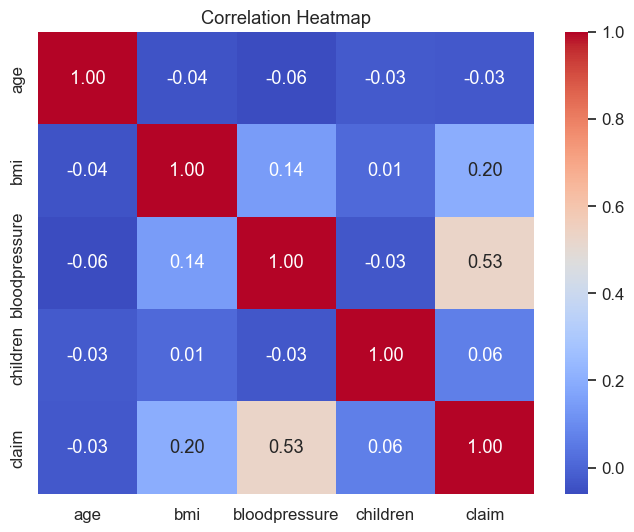

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()


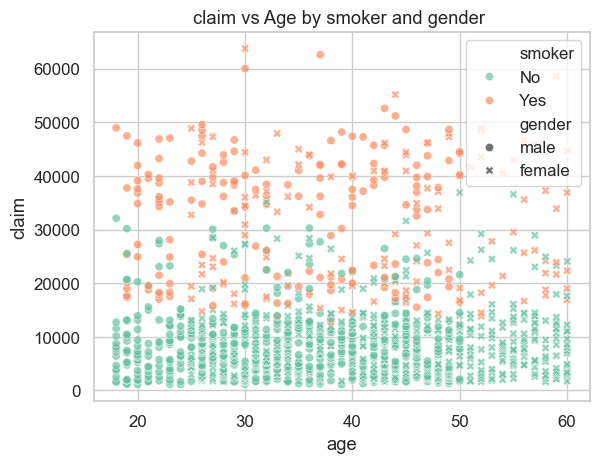

In [27]:
sns.scatterplot(data = df, x = 'age', y = 'claim', hue = 'smoker', style = 'gender', alpha = 0.7 )
plt.title('claim vs Age by smoker and gender ')
plt.show()

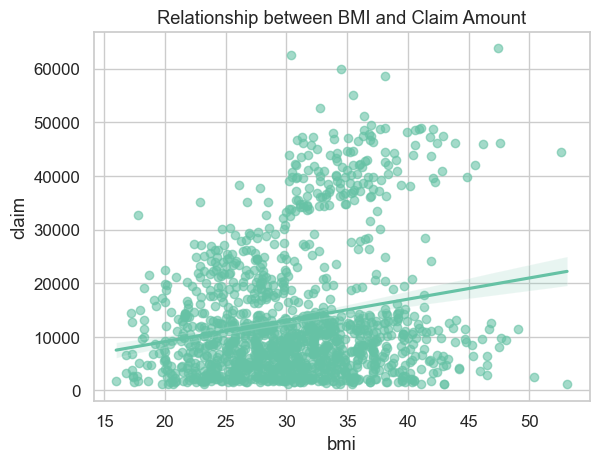

In [28]:
sns.regplot(data = df, x = 'bmi', y = 'claim', scatter_kws = {'alpha': 0.6})
plt.title('Relationship between BMI and Claim Amount')
plt.show()

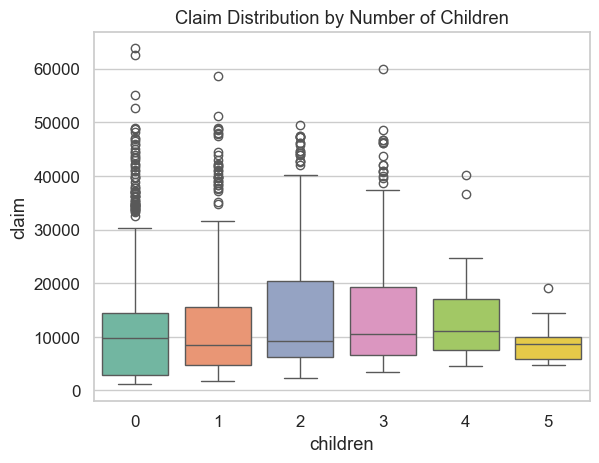

In [29]:
sns.boxplot(data = df, x = 'children', y = 'claim', hue = 'children', palette ='Set2', legend = False)
plt.title('Claim Distribution by Number of Children')
plt.show()

In [30]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46


In [31]:
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 30, 45, 60, 100], labels = ['<18', '18-30', '31-45', '46-60', '60+'])

In [32]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30


In [33]:
df.age_group.value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

In [34]:
sns.set(style = 'whitegrid', palette = 'Set2', font_scale =1.1)

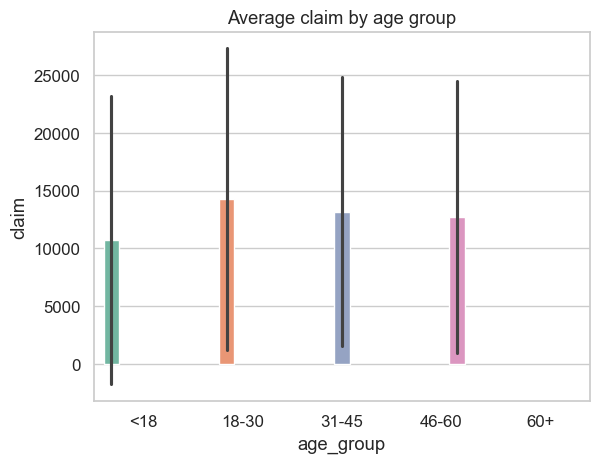

In [35]:
sns.barplot(
    data=df,
    x='age_group',
    y='claim',
    hue='age_group',        # 👈 add this
    estimator='mean',
    errorbar='sd',
    palette='Set2',
    legend=False            # 👈 remove duplicate legend
)

plt.title('Average claim by age group')
plt.show()

In [36]:
df['bmi_category'] = pd.cut(df['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], labels = ['Underweight', 'Normal', 'Overweight', 'Obese' ])

In [37]:
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

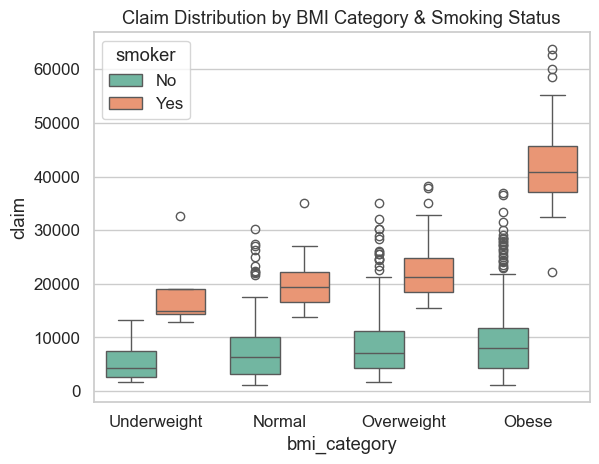

In [38]:
sns.boxplot(
    data=df,
    x='bmi_category',
    y='claim',
    hue='smoker',     
)

plt.title('Claim Distribution by BMI Category & Smoking Status')
plt.show()

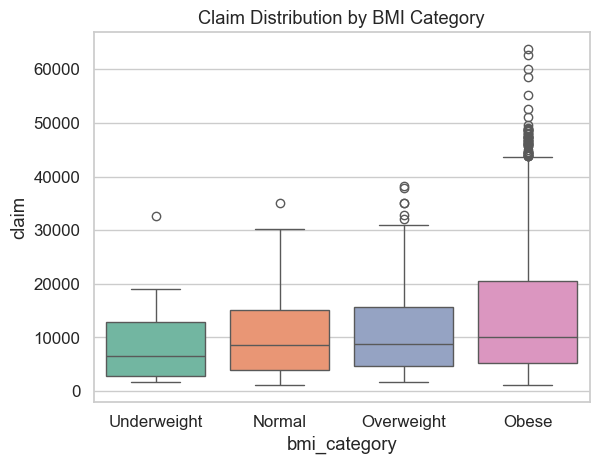

In [39]:
sns.boxplot(
    data=df,
    x='bmi_category',
    y='claim',
    hue = 'bmi_category'
)

plt.title('Claim Distribution by BMI Category')
plt.show()

In [40]:
import warnings
warnings.filterwarnings('ignore')

# FEATURE ENGINEERING

## Smoker Rate and Claim Ratio by Region

In [41]:
region_stats = df.groupby('region').agg(
    smoker_rate = ('smoker', lambda x: (x=='Yes').mean() * 100),
    mean_claim = ('claim', 'mean')
).reset_index()

In [42]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


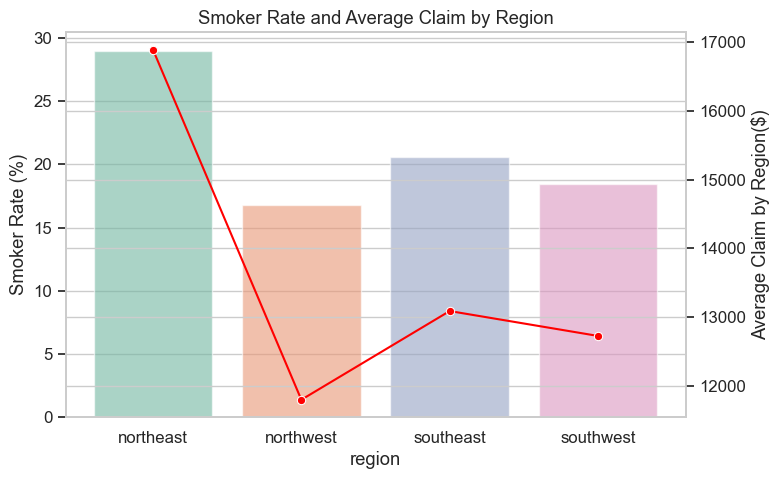

In [43]:
fig, ax1 = plt.subplots(figsize = (8,5))
sns.barplot(data = region_stats, x='region', y= 'smoker_rate', hue = 'region', ax= ax1, alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x = 'region', y ='mean_claim', ax = ax2, color = 'red', marker = 'o')
ax1.set_ylabel('Smoker Rate (%)')   
ax2.set_ylabel('Average Claim by Region($)')
plt.title('Smoker Rate and Average Claim by Region')
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [45]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [46]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [47]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [48]:
cat_cols = ['gender', 'diabetic', 'smoker']
label_encoders = {}

In [49]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f'label_encoder_{col}.pkl')

In [50]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [51]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [53]:
num_cols = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()

In [54]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [55]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [56]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [57]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [58]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


In [59]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {'R2' : r2, 'MAE': mae, 'RMSE' : rmse}
    

In [60]:
results = {}

In [61]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print('Linear Regression model trained')


best_poly_model = None
best_poly_score = -np.inf

for degree in [2,1]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)


    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:

        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results[f'Polynomial Regression (deg = (degree)) )'] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)

print('Polynomial Regression models are trained')


rf = RandomForestRegressor()


rf_params = { 'n_estimators': [100, 200],
        'max_depth' : [None, 10, 20],
        'min_samples_split' : [2, 5],
        'min_samples_leaf' : [1, 2]
        }

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results['Random Forest'] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print('Random Forest training is completed, best parameters', rf_grid.best_params_)


    
svr = SVR()

svr_params = {
    'kernel': ['rbf', 'poly', 'Linear'],
    'C': [1, 10, 50],
    'epsilon':[0.1, 0.2, 0.5],
    'degree': [2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring= 'r2', n_jobs = -1, verbose=0)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
results['SVR'] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print('SVR training is completed, best parameters:', svr_grid.best_params_ )

xgb = XGBRegressor(objective = 'reg:squarederror')

xgb_params = {'n_estimators': [100, 200],
              'max_depth': [3,5,7],
              'Learning_rate':[0.01, 0.05, 0.1],
              'subsample':[0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_


results['XGBoost'] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print('XGBoost training is completed, best parameters:', xgb_grid.best_params_)

Linear Regression model trained
Polynomial Regression models are trained
Random Forest training is completed, best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is completed, best parameters: {'C': 50, 'degree': 3, 'epsilon': 0.5, 'kernel': 'poly'}
XGBoost training is completed, best parameters: {'Learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [62]:
 results

{'Linear Regression': {'R2': 0.7265587526791166,
  'MAE': 4729.601370404982,
  'RMSE': np.float64(6219.476189263235)},
 'Polynomial Regression (deg = (degree)) )': {'R2': 0.7952284219211553,
  'MAE': 4047.7389036868863,
  'RMSE': np.float64(5382.1603794979765)},
 'Random Forest': {'R2': 0.8270465232863381,
  'MAE': 3738.947979711339,
  'RMSE': np.float64(4946.368235933019)},
 'SVR': {'R2': 0.25024495843414973,
  'MAE': 6796.722003704182,
  'RMSE': np.float64(10298.678332353955)},
 'XGBoost': {'R2': 0.7984477342264784,
  'MAE': 4059.9339457148294,
  'RMSE': np.float64(5339.685010364586)}}

In [63]:
results_df = pd.DataFrame(results).T.sort_values(by = 'R2', ascending = False)
results_df

,R2,MAE,RMSE
Random Forest,0.83,3738.95,4946.37
XGBoost,0.80,4059.93,5339.69
Polynomial Regression (deg = (degree)) ),0.80,4047.74,5382.16
Linear Regression,0.73,4729.60,6219.48
SVR,0.25,6796.72,10298.68


In [64]:
models = {'Linear Regression': poly_lr,
          'Polynomial Regression': poly_lr,
          'Random Forest': best_rf,
          'SVR': best_svr,
          'XGBoost': best_xgb
}

In [65]:
best_r2 = results_df['R2'].max()

In [66]:
best_r2

np.float64(0.8270465232863381)

In [67]:
top_model = results_df[results_df['R2'] == best_r2]

In [68]:
top_model

,R2,MAE,RMSE
Random Forest,0.83,3738.95,4946.37


In [69]:
best_model = models[top_model.index[0]]

In [70]:
best_model

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200)

In [72]:
joblib.dump(best_model, 'best_model.pkl')
print(f'Best model selected: {top_model.index[0]}')

Best model selected: Random Forest
